In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv('Dataset_spine.csv')

In [5]:
df.head()

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [6]:
df['Class_att'] = df['Class_att'].map({'Abnormal' : 1, 'Normal':0})

/var/folders/_8/44m23sq52qlc0h9l7rh1nk1r0000gn/T/ipykernel_5269/2443567679.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df['pelvic incidence'], df[' pelvic tilt'], cmap = 'viridis',color = 'blue')


Text(0, 0.5, 'Pelvic Tilt')

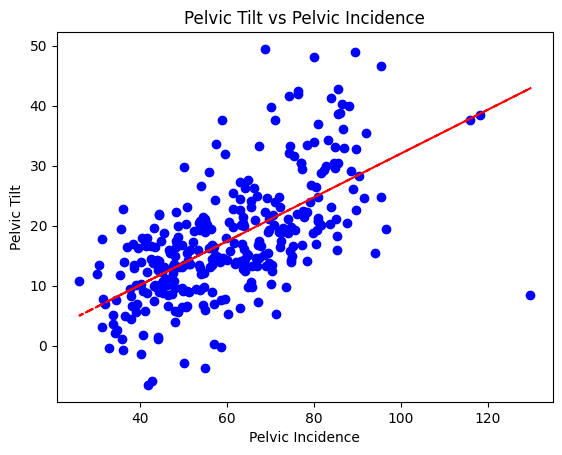

In [7]:
z = np.polyfit(df['pelvic incidence'],df[' pelvic tilt'],1)
p=np.poly1d(z)
plt.scatter(df['pelvic incidence'], df[' pelvic tilt'], cmap = 'viridis',color = 'blue')
plt.plot(df['pelvic incidence'],p(df['pelvic incidence']),"r--")
plt.title('Pelvic Tilt vs Pelvic Incidence')
plt.xlabel('Pelvic Incidence')
plt.ylabel('Pelvic Tilt')


<Axes: xlabel='pelvic incidence', ylabel='Count'>

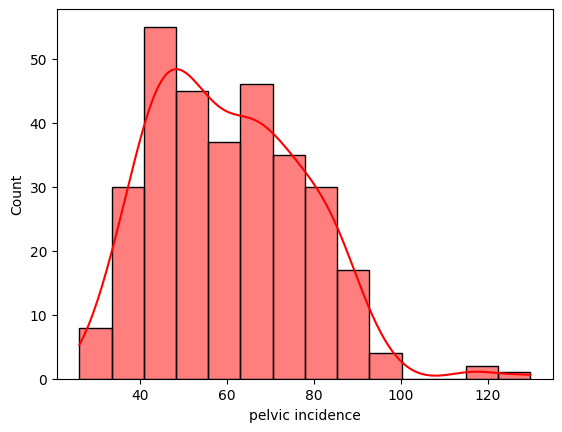

In [8]:

sns.histplot(data = df, x = 'pelvic incidence',kde = True,color='red')

<Axes: ylabel='Density'>

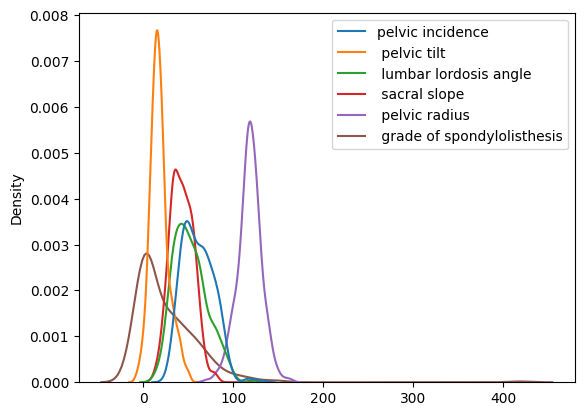

In [9]:
temp = df.drop(columns='Class_att')
sns.kdeplot(data = temp)

<Axes: >

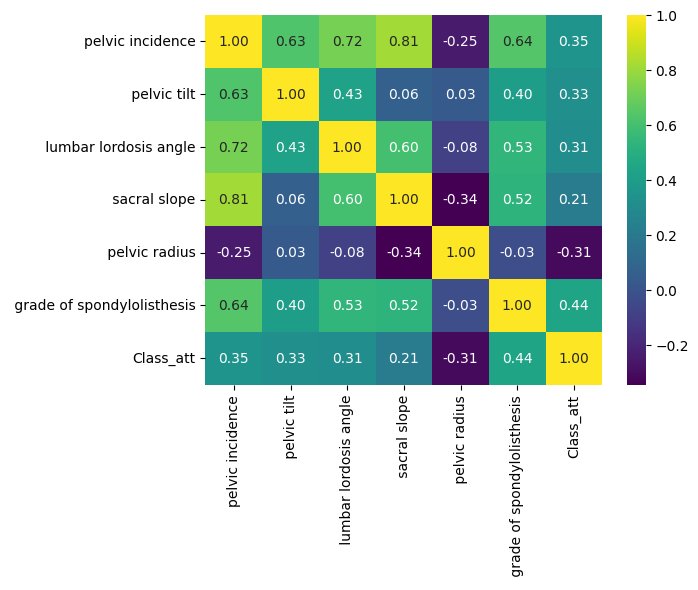

In [10]:
r = df.corr()
sns.heatmap(r,cmap='viridis',annot=True,fmt = '0.2f')

Text(0.5, 0.5, '0      63.027817\n1      39.056951\n2      68.832021\n3      69.297008\n4      49.712859\n         ...    \n305    47.903565\n306    53.936748\n307    61.446597\n308    45.252792\n309    33.841641\nName: pelvic incidence, Length: 310, dtype: float64')

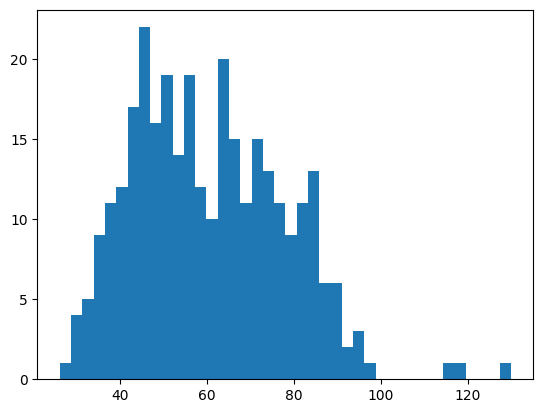

In [11]:
plt.hist(df['pelvic incidence'],bins = 40)
plt.annotate(text = df['pelvic incidence'],xy = [0.5,0.5])

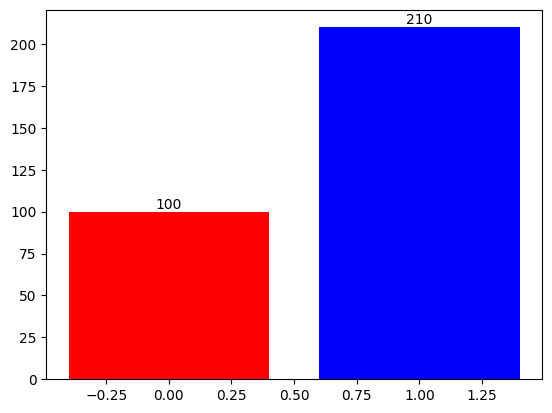

In [12]:
summary = df.groupby('Class_att')['pelvic incidence'].count().reset_index()

summary['Class_att'] = round(summary['Class_att'].astype(int))

plt.bar(summary['Class_att'],summary['pelvic incidence'],color = ['red','blue'])
for i, value in enumerate(summary['pelvic incidence']):
    plt.text(i,value + 2,str(value),ha = 'center')

Text(20, 20, 'Highest')

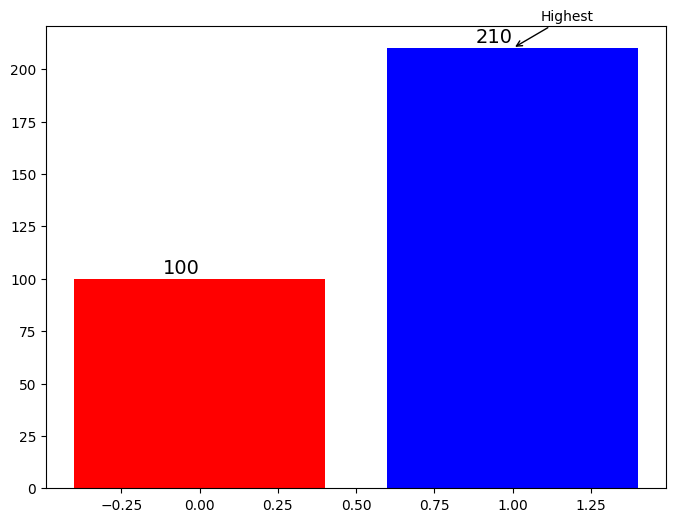

In [13]:
fig, axes = plt.subplots(figsize = (8,6))
axes.bar(summary['Class_att'],summary['pelvic incidence'],color = ['red','blue'])
highest_value = summary['pelvic incidence'].max()
highest_index = summary['pelvic incidence'].idxmax()
for i, value in enumerate(summary['pelvic incidence']):
    plt.annotate(str(value),
                (i,value)
                ,textcoords='offset points'
                ,xytext=(0,4),
                ha = 'right'
                ,fontsize = 14)
plt.annotate('Highest',
            (highest_index,highest_value),
             ha = 'left',
             textcoords= 'offset points',
              xytext = (20,20),
              arrowprops=dict(arrowstyle = '->')
                )

In [14]:
bins = np.linspace(df['pelvic incidence'].min().astype(int),df['pelvic incidence'].max().astype(int),10)
df['pelvic incidence bins'] = np.digitize(df['pelvic incidence'],bins=bins,right = True)

In [15]:
bins

array([ 26.        ,  37.44444444,  48.88888889,  60.33333333,
        71.77777778,  83.22222222,  94.66666667, 106.11111111,
       117.55555556, 129.        ])

In [16]:
df['pelvic incidence bins'].value_counts()

pelvic incidence bins
2     73
3     68
4     64
5     50
6     28
1     21
7      3
10     1
9      1
8      1
Name: count, dtype: int64

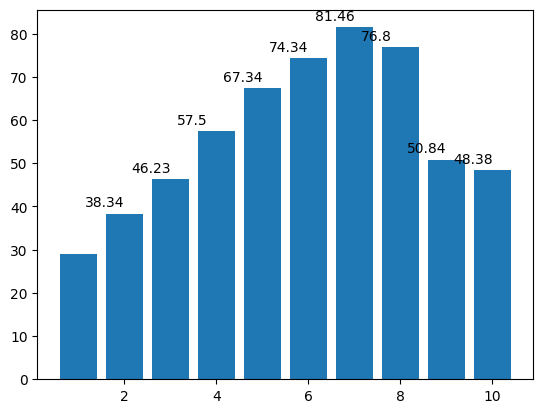

In [18]:
binned = df.groupby('pelvic incidence bins')[' lumbar lordosis angle'].mean().reset_index()

plt.bar(binned['pelvic incidence bins'], binned[' lumbar lordosis angle'])

for i, value in enumerate(binned[' lumbar lordosis angle']):
        plt.annotate(str(round(value,2))                    
                     ,xy = (i, value)
                    ,xytext = (5,5)
                    ,textcoords='offset points')

In [19]:
df.pivot(index = ['pelvic incidence', ' pelvic tilt'], columns = 'Class_att', values = ' lumbar lordosis angle')

,Class_att,0,1
pelvic incidence,pelvic tilt,,
26.147921,10.759454,NaN,14.000000
30.149936,11.917445,NaN,34.000000
30.741938,13.354966,35.903526,NaN
31.232387,17.715819,NaN,15.500000
31.276012,3.144669,NaN,32.562996
...,...,...,...
95.480229,46.550053,NaN,59.000000
96.657315,19.461581,NaN,90.211498
115.923261,37.515436,NaN,76.800000


Text(0.5, 1.0, 'Normal pelvic incidence distribution')

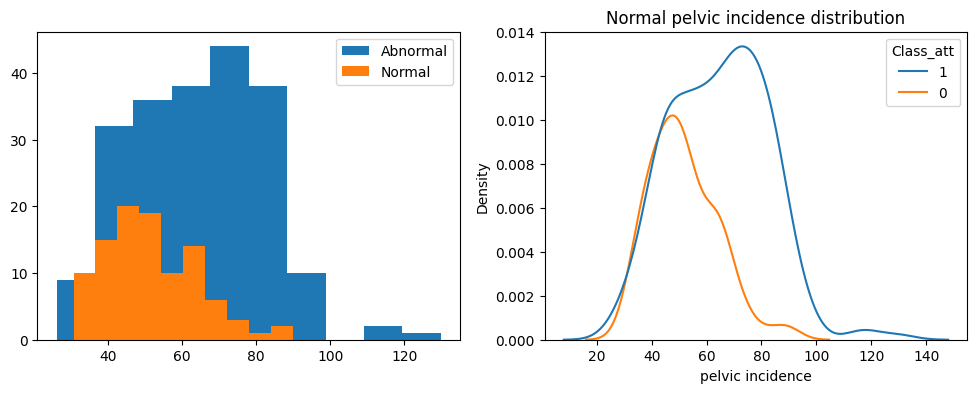

In [20]:
abnormal = df[df['Class_att'] == 1]
normal = df[df['Class_att'] == 0]
fig,axes = plt.subplots(1,2,figsize = (12,4))
axes[0].hist(abnormal['pelvic incidence'], label = 'Abnormal')
axes[0].hist(normal['pelvic incidence'], label = 'Normal')
axes[0].legend()
#axes[0].set_title('Abnormal pelvic incidence distribution')


sns.kdeplot(data = df, x = 'pelvic incidence', hue = 'Class_att', ax = axes[1], color = ['orange','blue'], hue_order = [1,0])
axes[1].set_title('Normal pelvic incidence distribution')

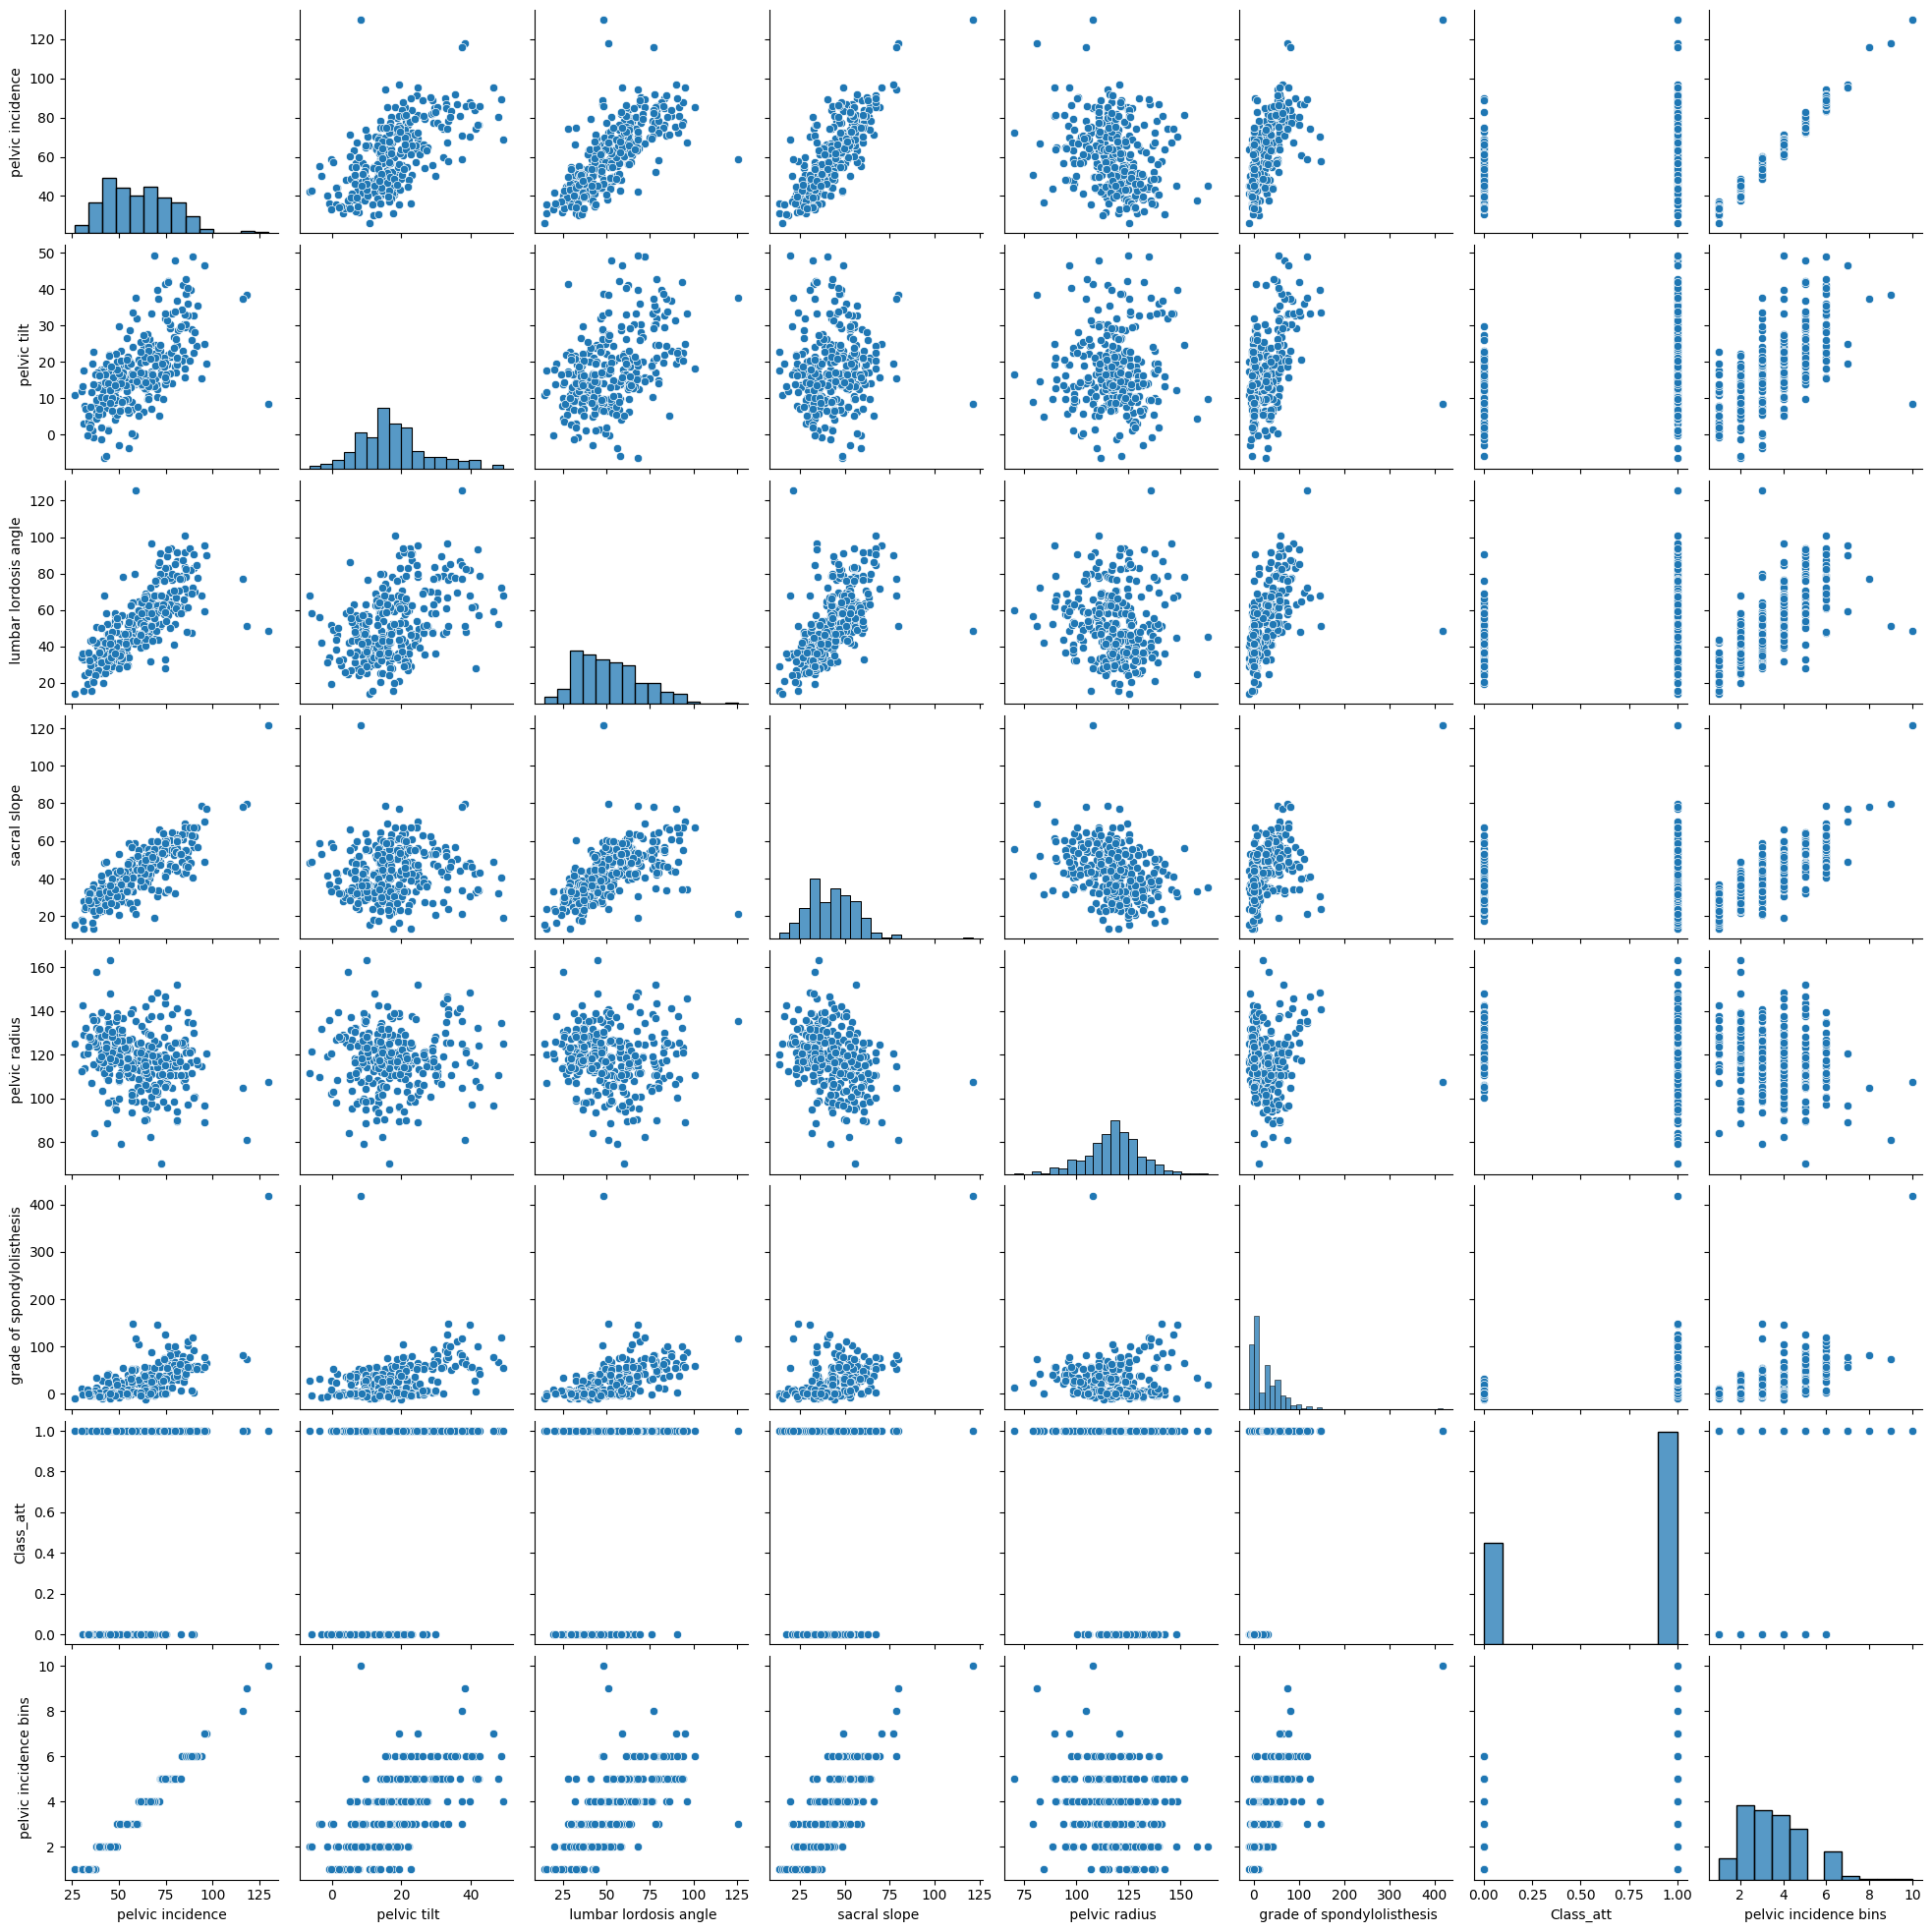

In [21]:
sns.pairplot(data = df, kind = 'scatter')

<Axes: >

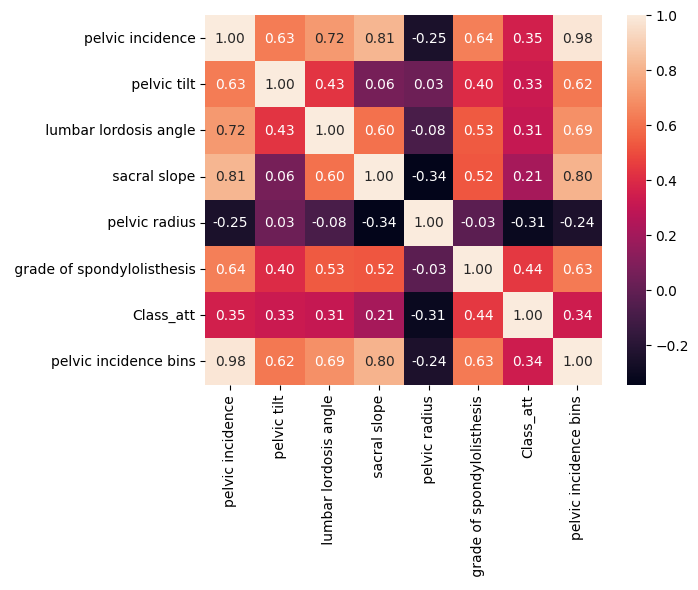

In [22]:
r = df.corr()
sns.heatmap(r,annot=True, fmt = '0.2f')

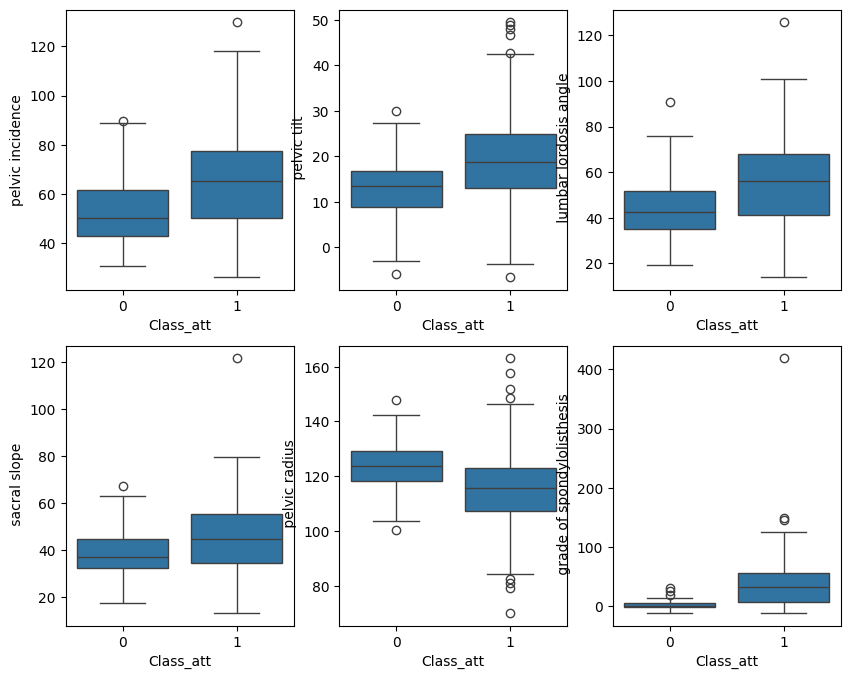

In [23]:
fig, axes = plt.subplots(2,3,figsize = (10,8))
features = (df.drop(columns = ['Class_att','pelvic incidence bins'])).columns
for idx,feature in enumerate(features):
    row,col = idx//3, idx%3
    sns.boxplot(data = df, x = 'Class_att', y = feature, ax = axes[row,col])

In [24]:
df['pi_category'] = pd.cut(x = df['pelvic incidence'],bins = 3, labels=['Low','Medium','High'])

<Axes: xlabel='pi_category'>

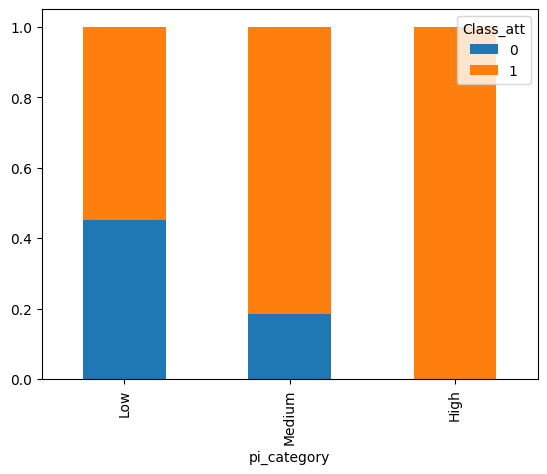

In [25]:
cross_tab = pd.crosstab(df['pi_category'], df['Class_att']).apply(lambda x: x/x.sum(), axis=1)
cross_tab.plot(kind = 'bar', stacked = True)


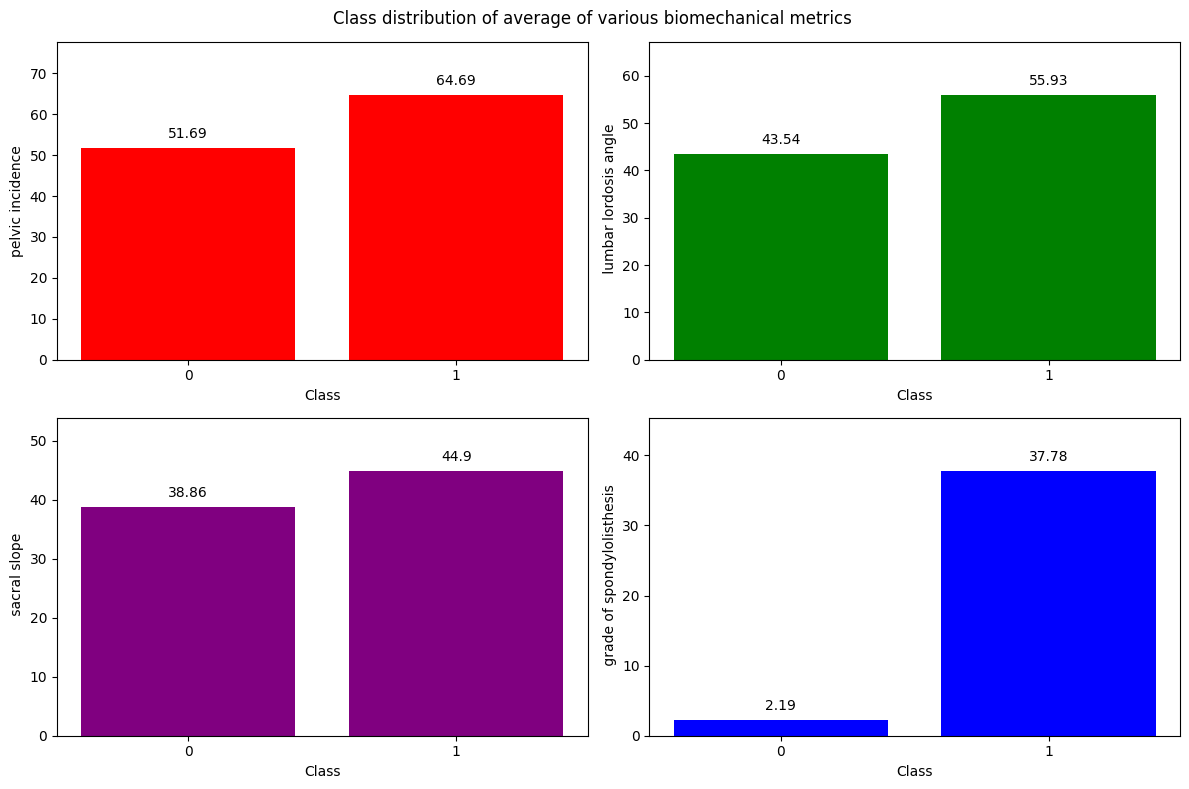

In [58]:
fig,axes = plt.subplots(2,2,figsize = (12,8))
features = ['pelvic incidence',' lumbar lordosis angle', ' sacral slope',' grade of spondylolisthesis']
class_map = {0:'coral',1:'grey'}
colors_chosen = ['red','green','purple','blue']

for idx, (feature,color) in enumerate(zip(features,colors_chosen)):
    row, col = idx//2, idx%2
    new_df = df.groupby('Class_att')[feature].mean().reset_index()
    #colors = [class_map[color] for color in new_df['Class_att']]
    new_df['Class_att'] = new_df['Class_att'].astype('str')
    axes[row,col].bar(new_df['Class_att'], new_df[feature], color = color)
    for i,value in enumerate(new_df[feature]):
        axes[row,col].annotate(str(round(value,2))
                     ,(i,value)
                     ,xytext = (0,5)
                     ,textcoords='offset points'
                     ,ha = 'center'
                     ,va = 'bottom')
    axes[row,col].set_xlabel('Class')
    axes[row,col].set_ylabel(feature)
    axes[row,col].set_ymargin(0.2)
    

plt.suptitle('Class distribution of average of various biomechanical metrics ')
plt.tight_layout()

In [56]:
cross_tab2 = pd.crosstab(df[' grade of spondylolisthesis'],df[' lumbar lordosis angle'])